<a href="https://colab.research.google.com/github/azharaul/ml-dl-projects/blob/main/Machine%20Learning/Loan%20Status%20Prediction/Tugas_Praktikum1ML_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum 1 ML
## Deskripsi Tugas

Pada tugas praktikum ini, peserta diminta untuk membuat model Artificial Intelligence (AI) dengan teknik klasifikasi menggunakan algoritma Logistic Regression pada dataset Loan Prediction yang telah disediakan.

Dataset dapat diunduh melalui file yang telah diberikan atau diakses melalui tautan berikut: https://www.kaggle.com/datasets/ssiddharth408/loan-prediction-dataset

Peserta diminta untuk melakukan seluruh tahapan pengembangan model, mulai dari Data Preparation, Data Understanding, Data Cleaning, Data Preprocessing, Modeling menggunakan Logistic Regression, hingga Evaluation. Setiap tahapan dikerjakan dengan mengisi kolom-kolom yang telah disediakan pada lembar praktikum.

Pada tahap Modeling, peserta wajib menggunakan algoritma Logistic Regression sebagai model klasifikasi untuk memprediksi hasil pengajuan pinjaman berdasarkan fitur-fitur yang tersedia pada dataset.

Pada tahap Evaluation, peserta diminta untuk menampilkan hasil performa model menggunakan Accuracy, Precision, Recall, dan F1-Score, serta menampilkan Confusion Matrix. Peserta juga perlu memberikan interpretasi sederhana terhadap hasil evaluasi, termasuk menjelaskan performa model dan hasil klasifikasi yang dihasilkan.

## Business Understanding

Dataset ini digunakan untuk memprediksi status pengajuan pinjaman berdasarkan informasi yang dimiliki oleh pemohon, seperti karakteristik pemohon dan informasi terkait pengajuan pinjaman.

Tujuan dari pembuatan model adalah membantu memprediksi apakah suatu pengajuan pinjaman akan disetujui atau tidak disetujui berdasarkan pola yang dipelajari dari data sebelumnya.

Output yang Diharapkan

Model diharapkan dapat menghasilkan salah satu dari dua kelas klasifikasi, yaitu:

Approved / Disetujui → pengajuan pinjaman diprediksi dapat disetujui.
Rejected / Tidak Disetujui → pengajuan pinjaman diprediksi tidak disetujui.

Dengan demikian, permasalahan yang dikerjakan merupakan Binary Classification (Klasifikasi Biner) karena memiliki dua kelas target.

# A. DATA PREPARATION

In [1]:
# Tools untuk EDA
import pandas as pd
import numpy as np

# Tools untuk Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Tools untuk data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression

# Tools untuk evaluasi model
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay
from sklearn.model_selection import cross_val_score


sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/tiyarsilearning/YARSIGENERATIVEAI/refs/heads/main/Tugas%201/dataset.csv')

# B. DATA UNDERSTANDING

In [3]:
# @title Menampilkan 5 data teratas
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [4]:
# @title Cek tipe data per-kolom, dan ukuran data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             601 non-null    object 
 2   married            611 non-null    object 
 3   dependents         599 non-null    object 
 4   education          614 non-null    object 
 5   self_employed      582 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# @title Cek statistik deskriptif dari data numerik
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# @title Cek statistik deskriptif dari data kategorikal
df.describe(exclude='number')

,loan_id,gender,married,dependents,education,self_employed,property_area,loan_status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,lp002990,male,yes,0,graduate,no,semiurban,y
freq,1,489,398,345,480,500,233,422


In [7]:
# @title Cek missing value
df.isna().sum()

,0
loan_id,0
gender,13
married,3
dependents,15
education,0
self_employed,32
applicantincome,0
coapplicantincome,0
loanamount,22
loan_amount_term,14


Memahami fitur yang akan di-handle missing value-nya

In [8]:
df['gender'].unique() # strategy='most_frequent'

array(['male', 'female', nan], dtype=object)

In [9]:
df['dependents'].unique() # strategy='most_frequent'

array(['0', '1', '2', '3+', nan], dtype=object)

In [10]:
df['self_employed'].unique() # strategy='most_frequent'

array(['no', 'yes', nan], dtype=object)

In [11]:
df['loanamount'].unique() # strategy='median'

array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [12]:
df['loan_amount_term'].unique() # strategy='most_frequent', soalnya datanya ga acak beda sama kolom loanamount

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [13]:
df['credit_history'].unique() # strategy='most_frequent'

array([ 1.,  0., nan])

In [14]:
# @title Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [15]:
# @title Cek nilai yang ga masuk akal
df[df[['loanamount', 'coapplicantincome', 'applicantincome']]<0].sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicantincome,0.0
coapplicantincome,0.0
loanamount,0.0
loan_amount_term,0.0


Berikut insight yang didapat dari proses data understanding
* Tidak ada data duplikat
* Kolom credit_history tipe datanya float, ubah jadi int biar jadi 1/0 bukan 1.0/2.0
* Kolom dependents isinya numerik, tapi tipe datanya object.
* Ada beberapa kolom yang memiliki missing values, diantaranya:
  * gender	= 13 / strategy='most_frequent'
  * married	= 3 / strategy='most_frequent'
  * dependents	= 15 / strategy='most_frequent'
  * self_employed	= 32 / strategy='most_frequent'
  * loanamount	= 22 / strategy='median'
  * loan_amount_term	= 14 / strategy='most_frequent'
  * credit_history	= 50 / strategy='most_frequent'

# C. DATA CLEANING
Hampir semua masalah yang didapat pada tahap DATA UNDERSTANDING, harus di handle setelah data train dan test di pisah. Jadi, fokus utama pada tahap data cleaning ini hanya menghapus kolom yang tidak berkorelasi dengan target


In [16]:
# @title Hapus kolom id
df = df.drop('loan_id', axis=1)

In [17]:
cat_cols = ['gender', 'married', 'dependents', 'education', 'self_employed', 'credit_history', 'property_area']
num_cols = ['applicantincome', 'coapplicantincome', 'loanamount']
term_col = ['loan_amount_term']

# D. EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
# @title Analisis data kategorikal (Mencari mana data biner, nominal, dan ordinal)
for i in cat_cols:
    print(f'{df[i].value_counts()}\n')

gender
male      489
female    112
Name: count, dtype: int64

married
yes    398
no     213
Name: count, dtype: int64

dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

education
graduate        480
not graduate    134
Name: count, dtype: int64

self_employed
no     500
yes     82
Name: count, dtype: int64

credit_history
1.0    475
0.0     89
Name: count, dtype: int64

property_area
semiurban    233
urban        202
rural        179
Name: count, dtype: int64



In [19]:
bin_cols = ['gender', 'married', 'education', 'self_employed']
credit_cols = ['credit_history'] # Kolom kredit dipisah soalnya dia data biner tapi tipe datanya numerik, jadi di data preprocessing nya beda.
ord_cols = ['dependents']
nom_cols = ['property_area']

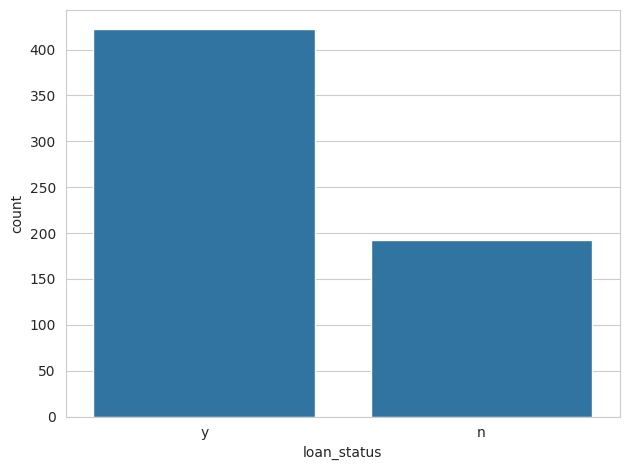

,count
loan_status,
y,422
n,192


In [47]:
# @title Analisis distribusi target
sns.countplot(data=df, x='loan_status')
plt.tight_layout()
plt.show()

df['loan_status'].value_counts()

Analisis data kategori dengan target

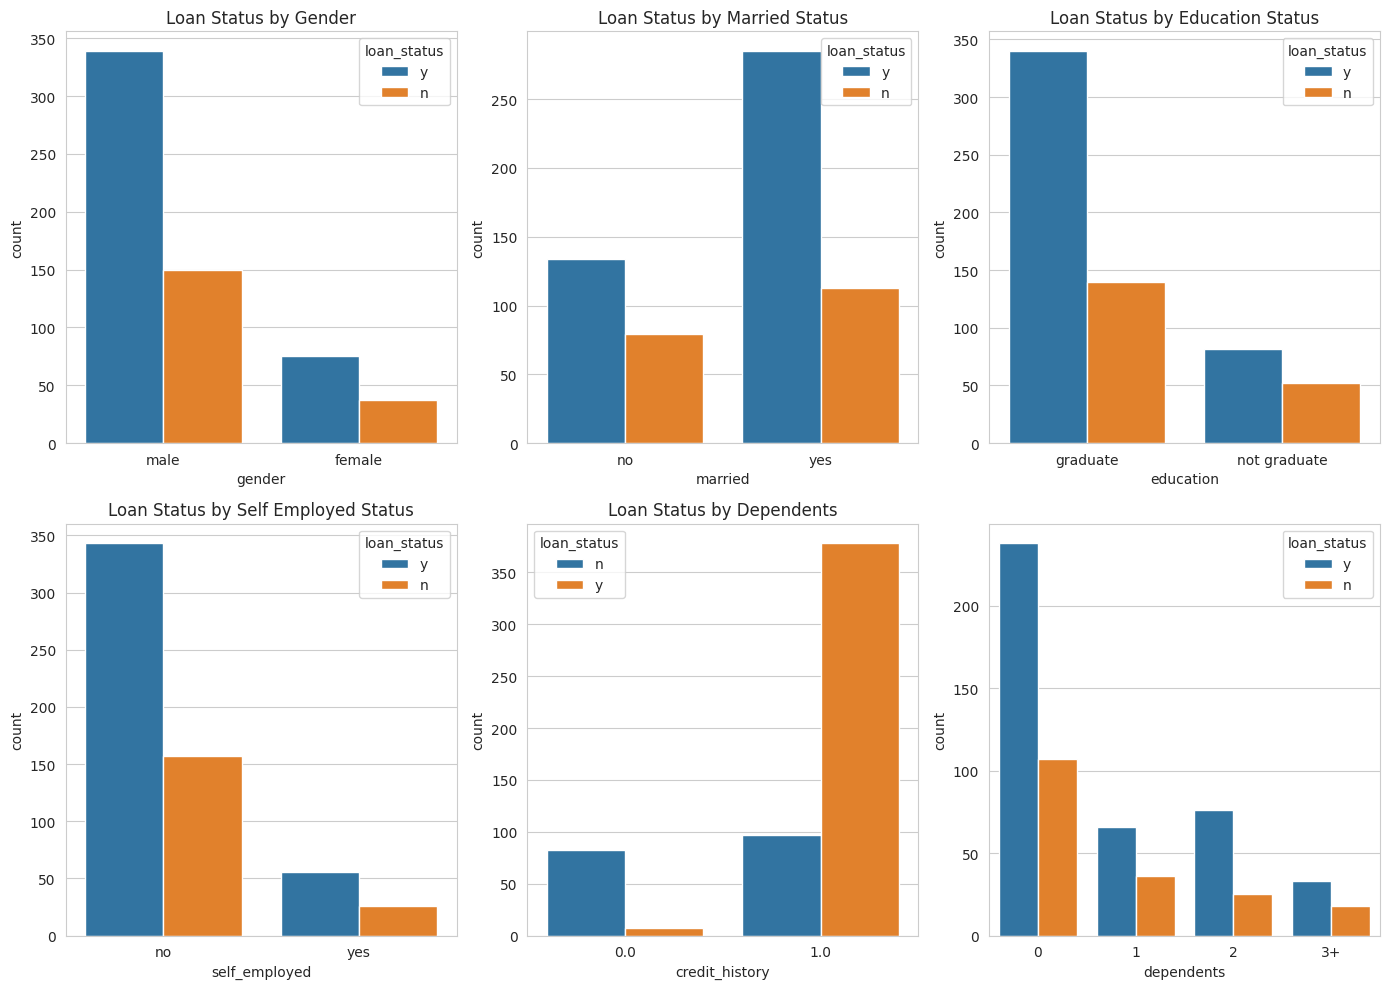

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14,10))
sns.countplot(data=df, x='gender', hue='loan_status', ax=axes[0][0])
axes[0][0].set_title('Loan Status by Gender')

sns.countplot(data=df, x='married', hue='loan_status', ax=axes[0][1])
axes[0][1].set_title('Loan Status by Married Status')

sns.countplot(data=df, x='education', hue='loan_status', ax=axes[0][2])
axes[0][2].set_title('Loan Status by Education Status')

sns.countplot(data=df, x='self_employed', hue='loan_status', ax=axes[1][0])
axes[1][0].set_title('Loan Status by Self Employed Status')

sns.countplot(data=df, x='credit_history', hue='loan_status', ax=axes[1][1])
axes[1][1].set_title('Loan Status by Self Credit History')

sns.countplot(data=df, x='dependents', hue='loan_status', ax=axes[1][2])
axes[1][1].set_title('Loan Status by Dependents')

plt.tight_layout()

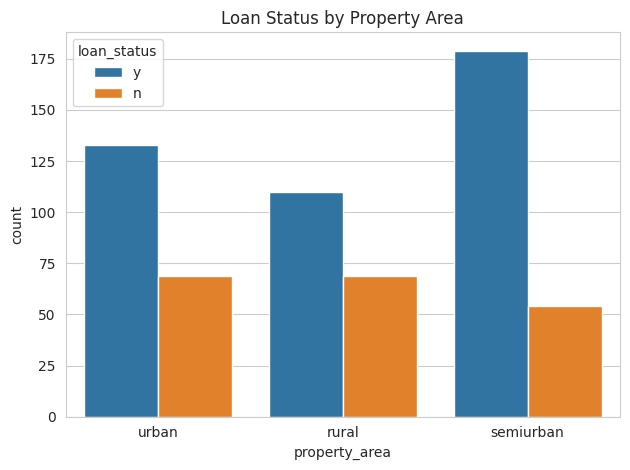

In [22]:
sns.countplot(data=df, x='property_area', hue='loan_status')
plt.title('Loan Status by Property Area')
plt.tight_layout()

Analisis data numerik dengan target

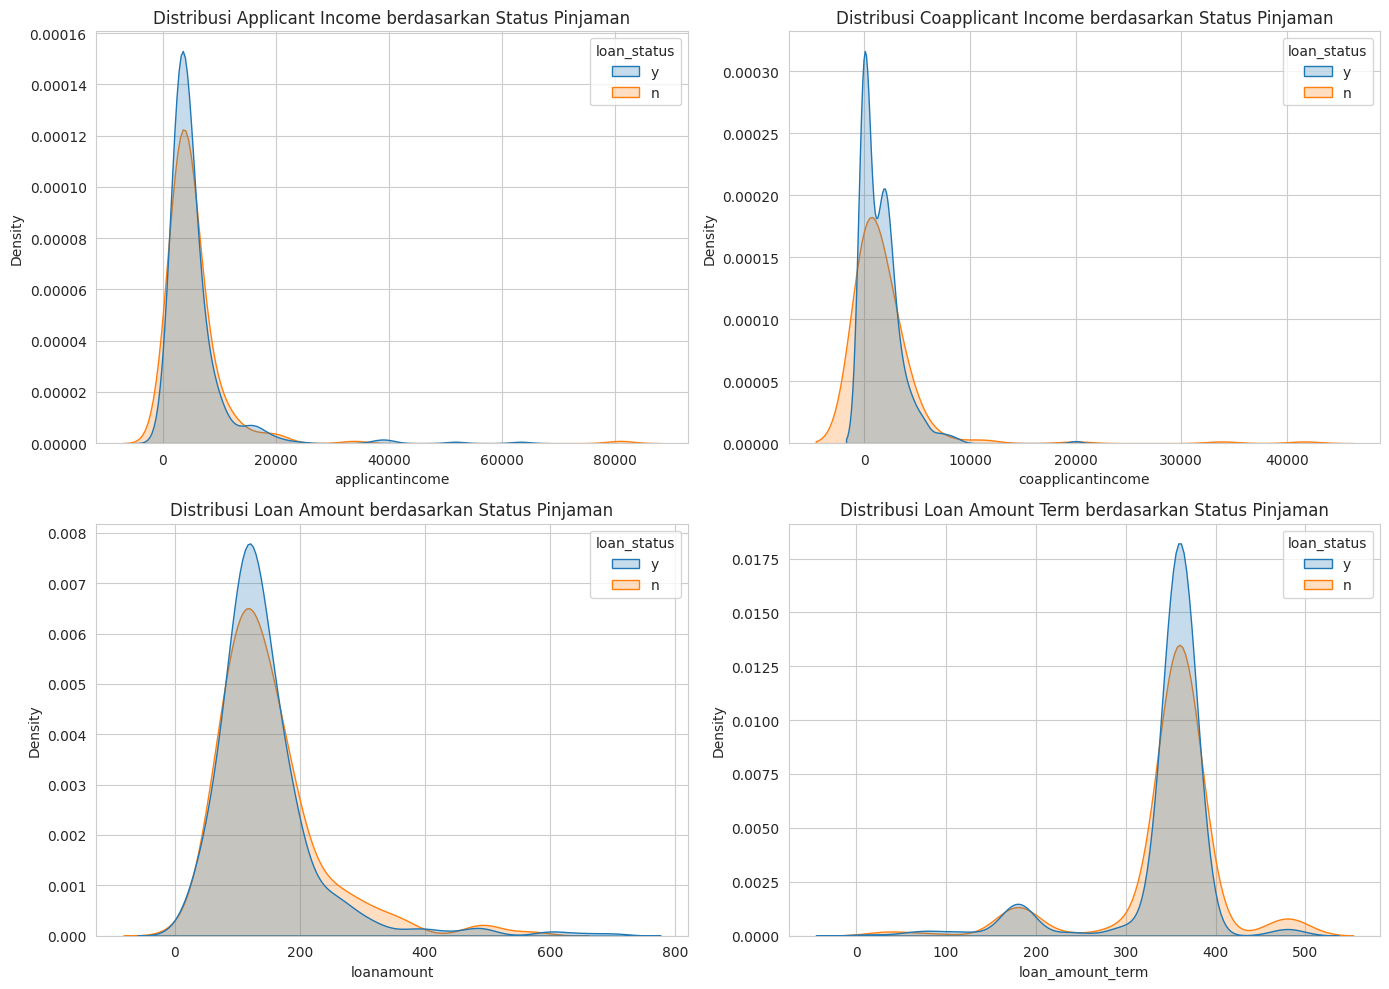

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.kdeplot(data=df, x='applicantincome', hue='loan_status', fill=True, common_norm=False, ax=axes[0][0])
axes[0][0].set_title('Distribusi Applicant Income berdasarkan Status Pinjaman')

sns.kdeplot(data=df, x='coapplicantincome', hue='loan_status', fill=True, common_norm=False, ax=axes[0][1])
axes[0][1].set_title('Distribusi Coapplicant Income berdasarkan Status Pinjaman')

sns.kdeplot(data=df, x='loanamount', hue='loan_status', fill=True, common_norm=False, ax=axes[1][0])
axes[1][0].set_title('Distribusi Loan Amount berdasarkan Status Pinjaman')

sns.kdeplot(data=df, x='loan_amount_term', hue='loan_status', fill=True, common_norm=False, ax=axes[1][1])
axes[1][1].set_title('Distribusi Loan Amount Term berdasarkan Status Pinjaman')

plt.tight_layout()


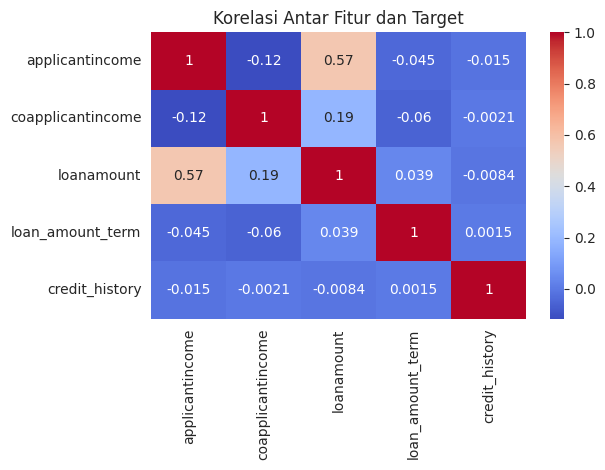

In [24]:
# @title Analisis korelasi antar fitur dan target
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur dan Target')
plt.tight_layout()

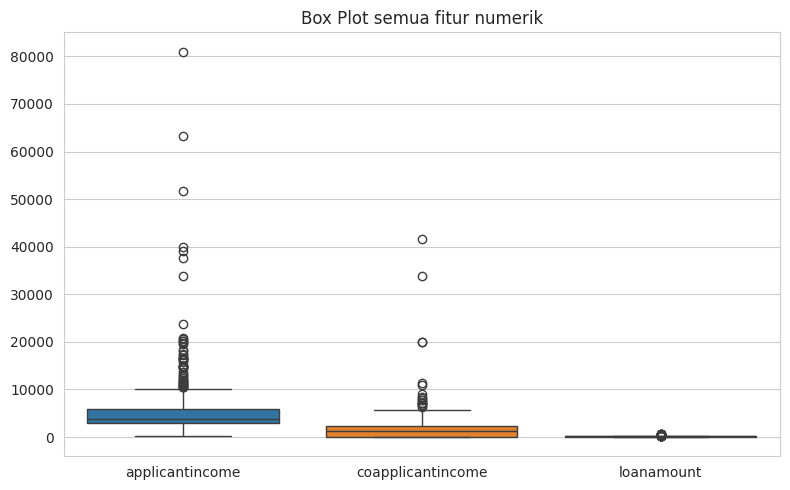

Jumlah outlier applicantincome: 50
Jumlah outlier coapplicantincome: 18
Jumlah outlier loanamount: 39


In [25]:
# @title Analisis outlier pada fitur numerik
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[num_cols])
plt.title('Box Plot semua fitur numerik')
plt.tight_layout()
plt.show()
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"Jumlah outlier {col}: {len(outliers)}")

# E. DATA PREPROCESSING

## Preprocessor Transformer Pipelines

In [26]:
preprocessor = ColumnTransformer([
    # preprocessing data biner
    ('bin', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
    ]), bin_cols),

    # preprocessing untuk kolom credit
    ('credit', SimpleImputer(strategy='most_frequent'), credit_cols),

    # preprocessing untuk data ordinal
    ('ord', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oe', OrdinalEncoder(categories=[['0', '1', '2', '3+']]))
    ]), ord_cols),

    # preprocessing untuk data nominal
    ('nom', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), nom_cols),

    # preprocessing untuk data numerik
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    # preprocessing untuk kolom loan_amount_term
    ('term', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler())
    ]), term_col)
])

## Data Splitting

In [27]:
X = df.drop(columns='loan_status')
y = df['loan_status'].map({'y':1, 'n':0})

In [28]:
X.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban
1,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural
2,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban
3,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban
4,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban


In [29]:
y.head()

,loan_status
0,1
1,0
2,1
3,1
4,1


## Train Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# F. MODELING

In [43]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

In [44]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'married',
                                                   'education',
                                                   'self_employed']),
                                                 ('credit',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['credit_history']),
                                                 ('ord',
                                                  Pipeline(steps=[('imp'...
                                                                                 handle_unknown='ignore'))]),
                                                  ['property_area']),
                                                 ('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['applicantincome',
                                                   'coapplicantincome',
                                                   'loanamount']),
                                                 ('term',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount_term'])])),
                ('model', LogisticRegression(random_state=42))])

# G. MODEL EVALUATION

In [33]:
model.score(X_test, y_test)

0.8617886178861789

In [34]:
y_preds = model.predict(X_test)

## Classification Metrics

In [45]:
# @title Metrik Akurasi
print(f"Skor Akurasi: {np.mean(accuracy_score(y_test, y_preds))*100:.2f}%")
print(f"Skor Presisi: {np.mean(precision_score(y_test, y_preds))*100:.2f}%")
print(f"Skor Recall: {np.mean(recall_score(y_test, y_preds))*100:.2f}%")
print(f"Skor F1: {np.mean(f1_score(y_test, y_preds))*100:.2f}%")

Skor Akurasi: 86.18%
Skor Presisi: 84.00%
Skor Recall: 98.82%
Skor F1: 90.81%


## Confusion Matrix

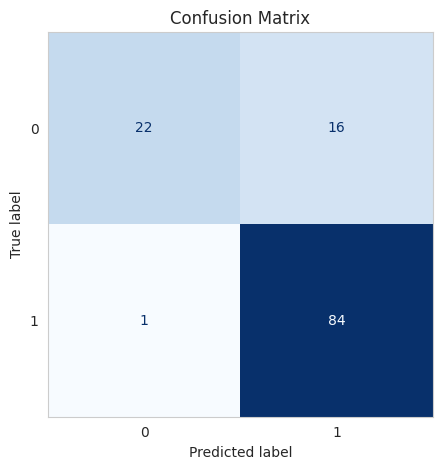

In [36]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_preds, cmap='Blues', colorbar=False)
disp.ax_.grid(False)
plt.title('Confusion Matrix')
plt.tight_layout()

## Classification Report

In [37]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



## Cross Validation Acc, Prec, Rec, F1

In [38]:
cv_acc = cross_val_score(model, X,y, scoring='accuracy')
cv_prec = cross_val_score(model, X,y, scoring='precision')
cv_rec = cross_val_score(model, X,y, scoring='recall')
cv_f1 = cross_val_score(model, X,y, scoring='f1')
print(f'CV Score Accuracy: {np.mean(cv_acc)*100:.2f}%')
print(f'CV Score Precision: {np.mean(cv_prec)*100:.2f}%')
print(f'CV Score Recall: {np.mean(cv_rec)*100:.2f}%')
print(f'CV Score F1: {np.mean(cv_f1)*100:.2f}%')

CV Score Accuracy: 80.78%
CV Score Precision: 79.06%
CV Score Recall: 98.11%
CV Score F1: 87.55%


## ROC AUC

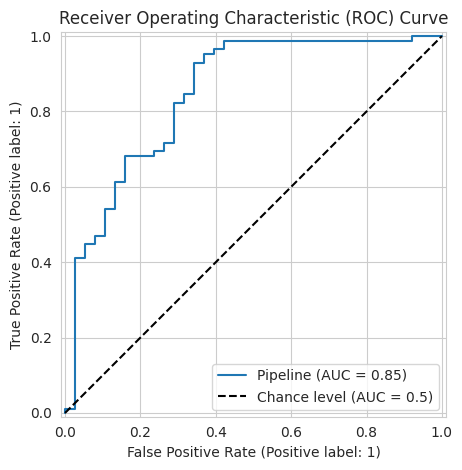

In [39]:
RocCurveDisplay.from_estimator(model, X_test, y_test, plot_chance_level=True)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.tight_layout()

AUC 0,85 menunjukkan model cukup mampu membedakan pinjaman yang disetujui dan ditolak.

# Interpretasi Hasil Evaluasi
Model cenderung terlalu mudah memprediksi kelas 1/y (menyetujui pinjaman). Hal ini  dikarenakan datanya tidak seimbang (kelas 1/y jauh lebih banyak), sehingga model condong ke kelas mayoritas.

Akurasi test (86,18%) lebih tinggi dari rata-rata cross-validation (80,78%). Ini mungkin karena hasil di data uji atau test set-nya lebih banyak kelas 1/y, jadi skor dari Cross Validation lebih realistis sebagai perkiraan performa model pada data baru. Jadi `tidak ada tanda overfitting parah`, karena selisihnya kecil dan pola recall/precision konsisten antara test dan CV.

Kesimpulanya model sudah bagus karena akurasinya sekitar 81-86%, dan Skor AUC-nya 0,85, tapi masih lemah dalam memprediksi kelas 0/n karena dataya tidak seimbang.